<a href="https://colab.research.google.com/github/VielF/ColabProjects/blob/main/Pr%C3%A1tica_Filtragem_Espacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Universidade do Vale do Itajaí<br>
Escola Politécnica<br>
Processamento Digital de Sinais: Imagens

# Exercício Avaliativo de Filtragem Espacial

### Tutoriais da OpenCV

- https://docs.opencv.org/master/d9/df8/tutorial_root.html
- https://www.geeksforgeeks.org/opencv-python-tutorial/

## Importações e Configurações Iniciais

In [ ]:
#Guilherme Thomy, Pedro Kons e Vinicius Pereira
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
import io
from PIL import Image

## Upload da Imagem

Execute a célula abaixo para fazer upload da sua imagem de teste:

In [ ]:
# Upload da imagem
uploaded = files.upload()

# Pega o nome do primeiro arquivo enviado
image_name = list(uploaded.keys())[0]
print(f"Imagem carregada: {image_name}")

Saving imagemteste.jpg to imagemteste.jpg
Imagem carregada: imagemteste.jpg


## Conversão de imagem RGB em imagem Grayscale

Dimensões da imagem: (360, 540, 3)


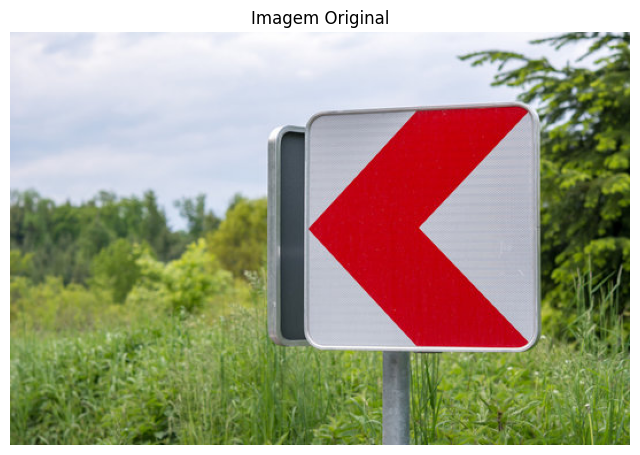

In [ ]:
# Carrega a imagem
img = cv2.imread(image_name, 1)
print(f"Dimensões da imagem: {img.shape}")

# Mostra a imagem original
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagem Original')
plt.axis('off')
plt.show()

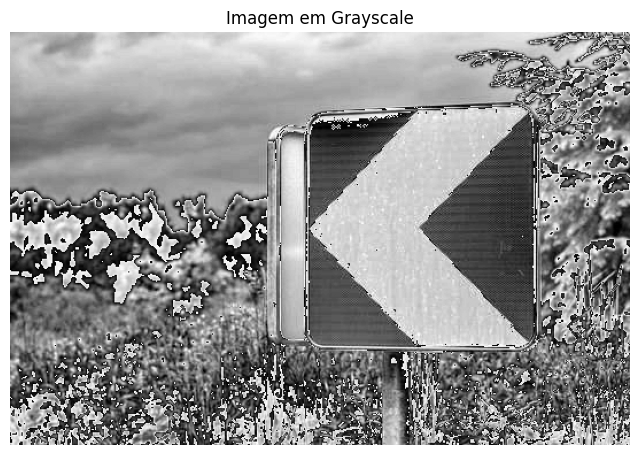

In [ ]:
# Aplicando conversão básica para grayscale
B, G, R = cv2.split(img)
img_gray = ((B + G + R) / 3).astype(np.uint8)  # conversão básica

# Mostra a imagem em grayscale
plt.figure(figsize=(8, 6))
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem em Grayscale')
plt.axis('off')
plt.show()

## Funções Auxiliares para Filtragem Espacial

In [ ]:
def gauss_create(sigma=1, size_x=3, size_y=3):
    """
    Cria um kernel Gaussiano
    """
    x, y = np.meshgrid(np.linspace(-1,1,size_x), np.linspace(-1,1,size_y))
    calc = 1 / (2 * np.pi * (sigma**2))
    exp = np.exp(-(((x**2) + (y**2)) / (2 * (sigma**2))))
    kernel = calc * exp
    kernel /= np.sum(kernel)   # Normaliza o kernel
    return kernel

def add_padding(img, pad_h, pad_w):
    """
    Adiciona padding zero à imagem
    """
    n, m = img.shape
    padded = np.zeros((n + pad_h * 2, m + pad_w * 2))
    padded[pad_h:n+pad_h, pad_w:m+pad_w] = img
    return padded

def conv2d(img, kernel, padding=True):
    """
    Implementação manual de convolução 2D
    """
    k_h, k_w = kernel.shape
    i_h, i_w = img.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    if padding:
        padded = add_padding(img, pad_h, pad_w)
    else:
        padded = img

    out = np.zeros((i_h, i_w), dtype=float)
    for i in range(i_h):
        for j in range(i_w):
            region = padded[i:i+k_h, j:j+k_w]
            out[i, j] = np.sum(region * kernel)

    return np.clip(out, 0, 255).astype(np.uint8)

## Filtros de Suavização

Implementação dos filtros de média, gaussiano e mediana com máscaras 3x3, 5x5 e 7x7

In [ ]:
# ---- Filtros de suavização ----
def mean_filter(size):
    """
    Cria um filtro de média
    """
    return np.ones((size, size)) / (size * size)

def gaussian_filter(size, sigma=1):
    """
    Cria um filtro Gaussiano
    """
    return gauss_create(sigma=sigma, size_x=size, size_y=size)

def median_filter(img, size):
    """
    Aplica filtro de mediana
    """
    i_h, i_w = img.shape
    pad = size // 2
    padded = add_padding(img, pad, pad)
    out = np.zeros((i_h, i_w), dtype=float)
    for i in range(i_h):
        for j in range(i_w):
            region = padded[i:i+size, j:j+size].flatten()
            out[i, j] = np.median(region)
    return np.array(out, dtype=np.uint8)

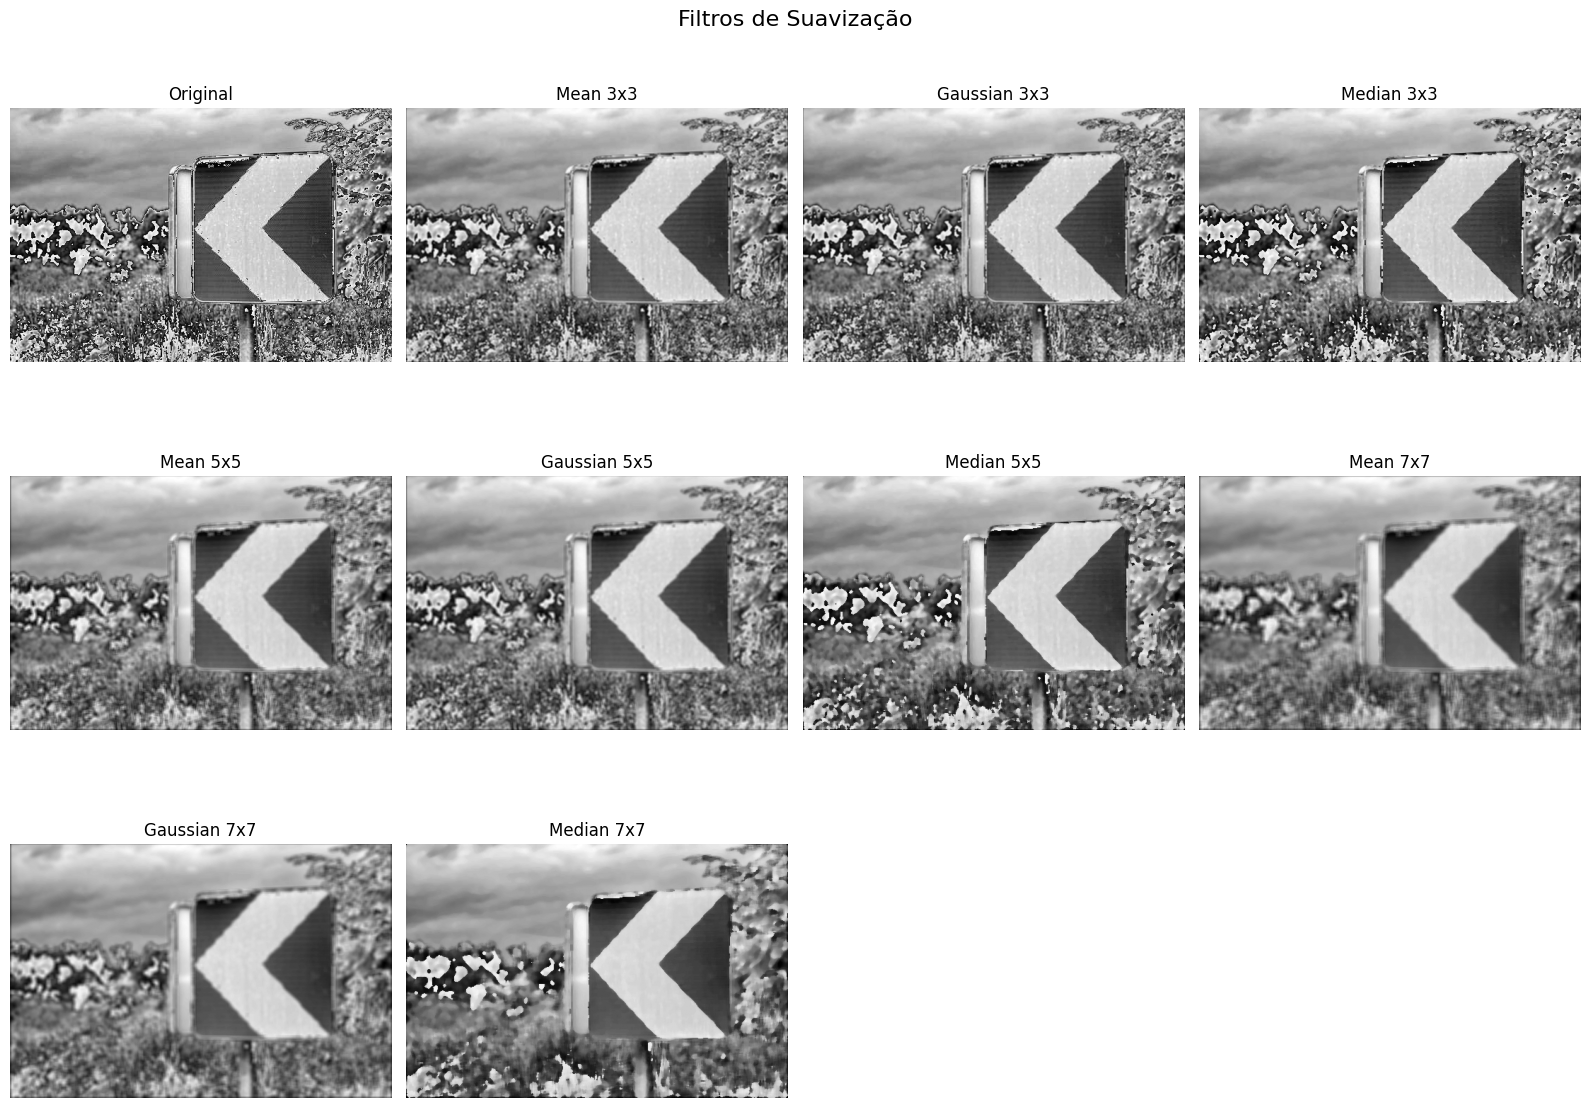

In [ ]:
# Aplicação dos filtros de suavização
sizes = [3, 5, 7]
results_smooth = {"Original": img_gray}

for size in sizes:
    results_smooth[f"Mean {size}x{size}"] = conv2d(img_gray, mean_filter(size))
    results_smooth[f"Gaussian {size}x{size}"] = conv2d(img_gray, gaussian_filter(size, sigma=1.0))
    results_smooth[f"Median {size}x{size}"] = median_filter(img_gray, size)

# Função para plotar resultados
def plot_results(results, title):
    cols = 4
    rows = (len(results) + cols - 1) // cols
    plt.figure(figsize=(16, 12))
    for idx, (t, img) in enumerate(results.items()):
        plt.subplot(rows, cols, idx+1)
        plt.imshow(img, cmap='gray')
        plt.title(t)
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_results(results_smooth, "Filtros de Suavização")

## Filtros de Sharpening

Implementação dos filtros Laplaciano, Sharpening, Unsharp Masking e Highboost Filtering

In [ ]:
# ---- Filtros de Sharpening ----
def laplacian_filter(img):
    """
    Aplica filtro Laplaciano
    """
    kernel = np.array([[0, -1, 0],
                       [-1, 4, -1],
                       [0, -1, 0]])
    return conv2d(img, kernel)

def sharpen_filter(img):
    """
    Aplica filtro de sharpening
    """
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return conv2d(img, kernel)

def unsharp_mask(img, size=5, sigma=1.0, k=1.0):
    """
    Aplica Unsharp Masking
    """
    kernel_gauss = gaussian_filter(size, sigma)
    blurred = conv2d(img, kernel_gauss)
    mask = img.astype(float) - blurred.astype(float)
    result = img.astype(float) + k * mask
    return np.clip(result, 0, 255).astype(np.uint8)

def highboost_filter(img, size=5, sigma=1.0, k=1.5):
    """
    Aplica Highboost Filtering
    """
    return unsharp_mask(img, size=size, sigma=sigma, k=k)

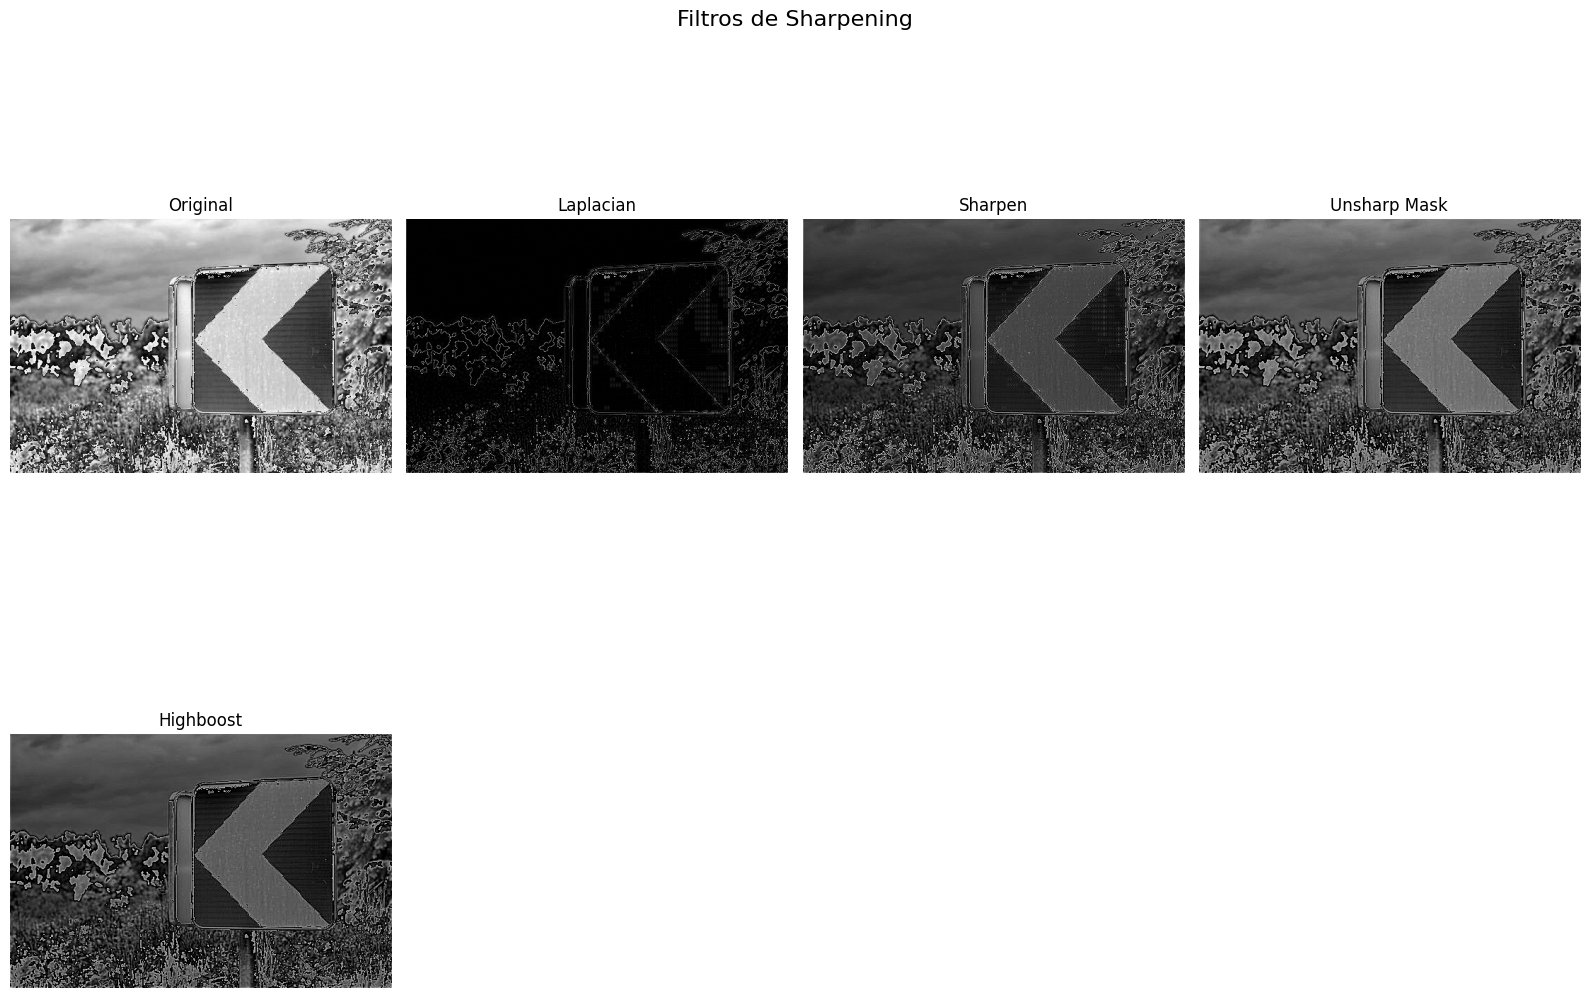

In [ ]:
# Aplicação dos filtros de sharpening
results_sharp = {
    "Original": img_gray,
    "Laplacian": laplacian_filter(img_gray),
    "Sharpen": sharpen_filter(img_gray),
    "Unsharp Mask": unsharp_mask(img_gray, k=1.0),
    "Highboost": highboost_filter(img_gray, k=1.5)
}

plot_results(results_sharp, "Filtros de Sharpening")

## Detectores de Borda

Implementação dos detectores Roberts, Sobel, Laplaciano e Canny

In [ ]:
# ---- Detectores de borda ----
def roberts_edge(img):
    """
    Detector de bordas Roberts
    """
    kx = np.array([[1, 0],
                   [0, -1]])
    ky = np.array([[0, 1],
                   [-1, 0]])
    gx = conv2d(img, kx, padding=False)
    gy = conv2d(img, ky, padding=False)
    grad = np.sqrt(gx.astype(float)**2 + gy.astype(float)**2)
    return np.clip(grad, 0, 255).astype(np.uint8)

def sobel_edge(img):
    """
    Detector de bordas Sobel
    """
    kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
    ky = np.array([[-1, -2, -1],
                   [0,  0,  0],
                   [1,  2,  1]])
    gx = conv2d(img, kx)
    gy = conv2d(img, ky)
    grad = np.sqrt(gx.astype(float)**2 + gy.astype(float)**2)
    return np.clip(grad, 0, 255).astype(np.uint8)

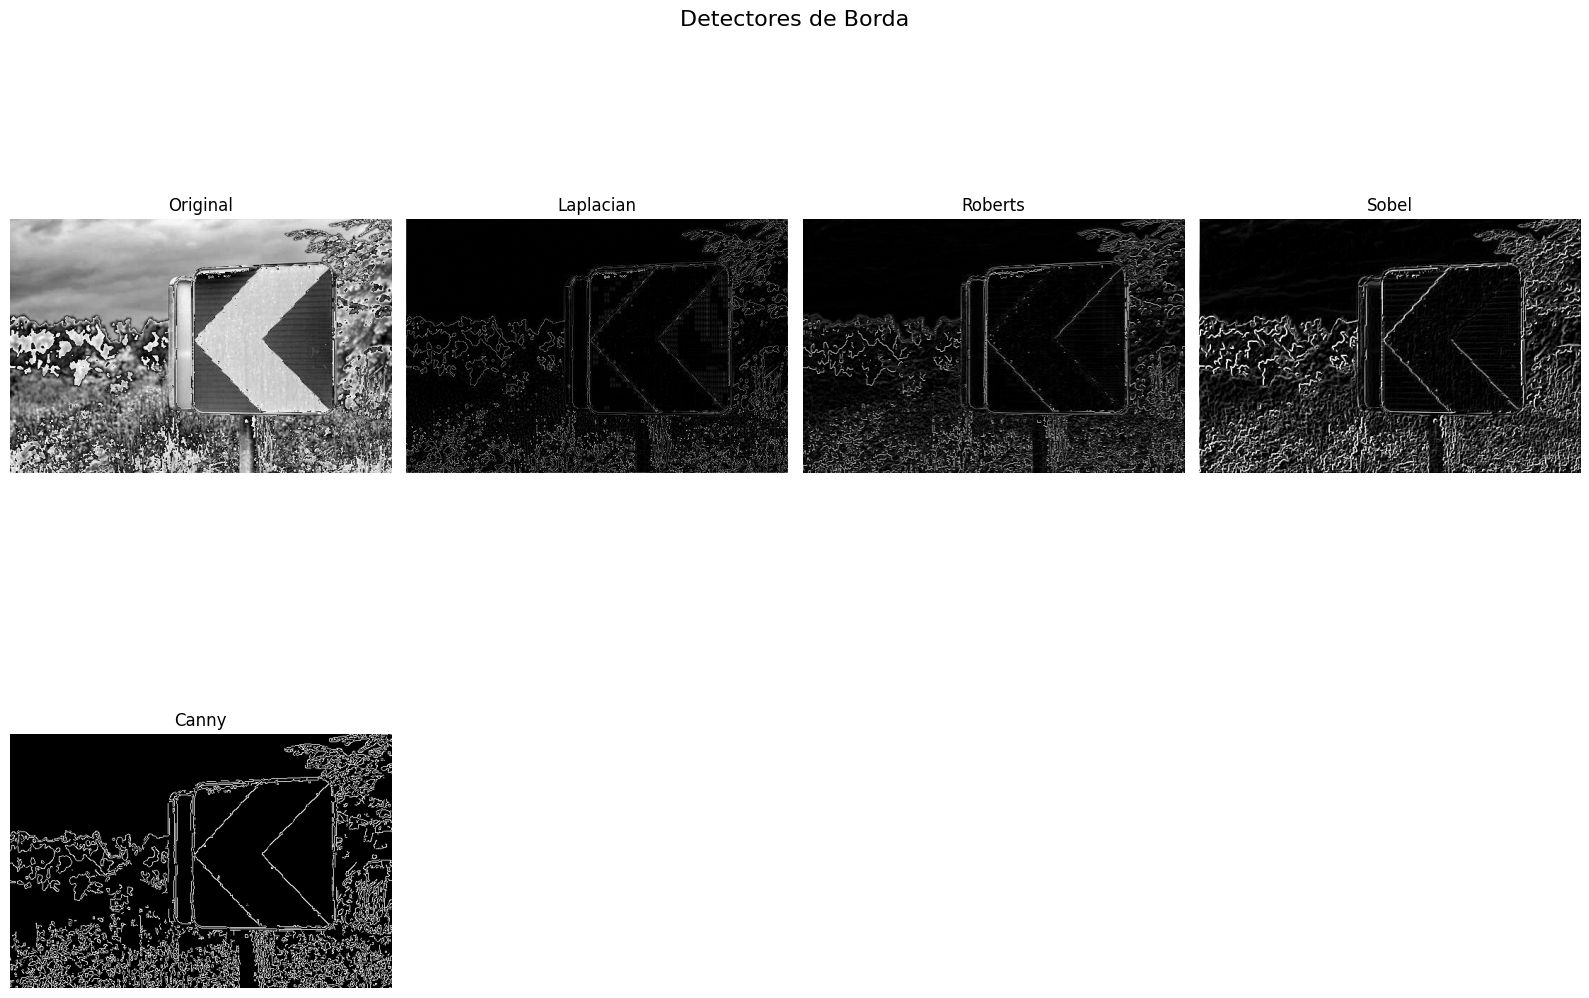

In [ ]:
# Aplicação dos detectores de borda
results_edges = {
    "Original": img_gray,
    "Laplacian": laplacian_filter(img_gray),
    "Roberts": roberts_edge(img_gray),
    "Sobel": sobel_edge(img_gray),
    "Canny": cv2.Canny(img_gray, 100, 200)  # OpenCV Canny
}

plot_results(results_edges, "Detectores de Borda")

## Comparação: Sobel com Suavização vs Canny

Aplicação do filtro Sobel após operação de suavização e comparação com Canny

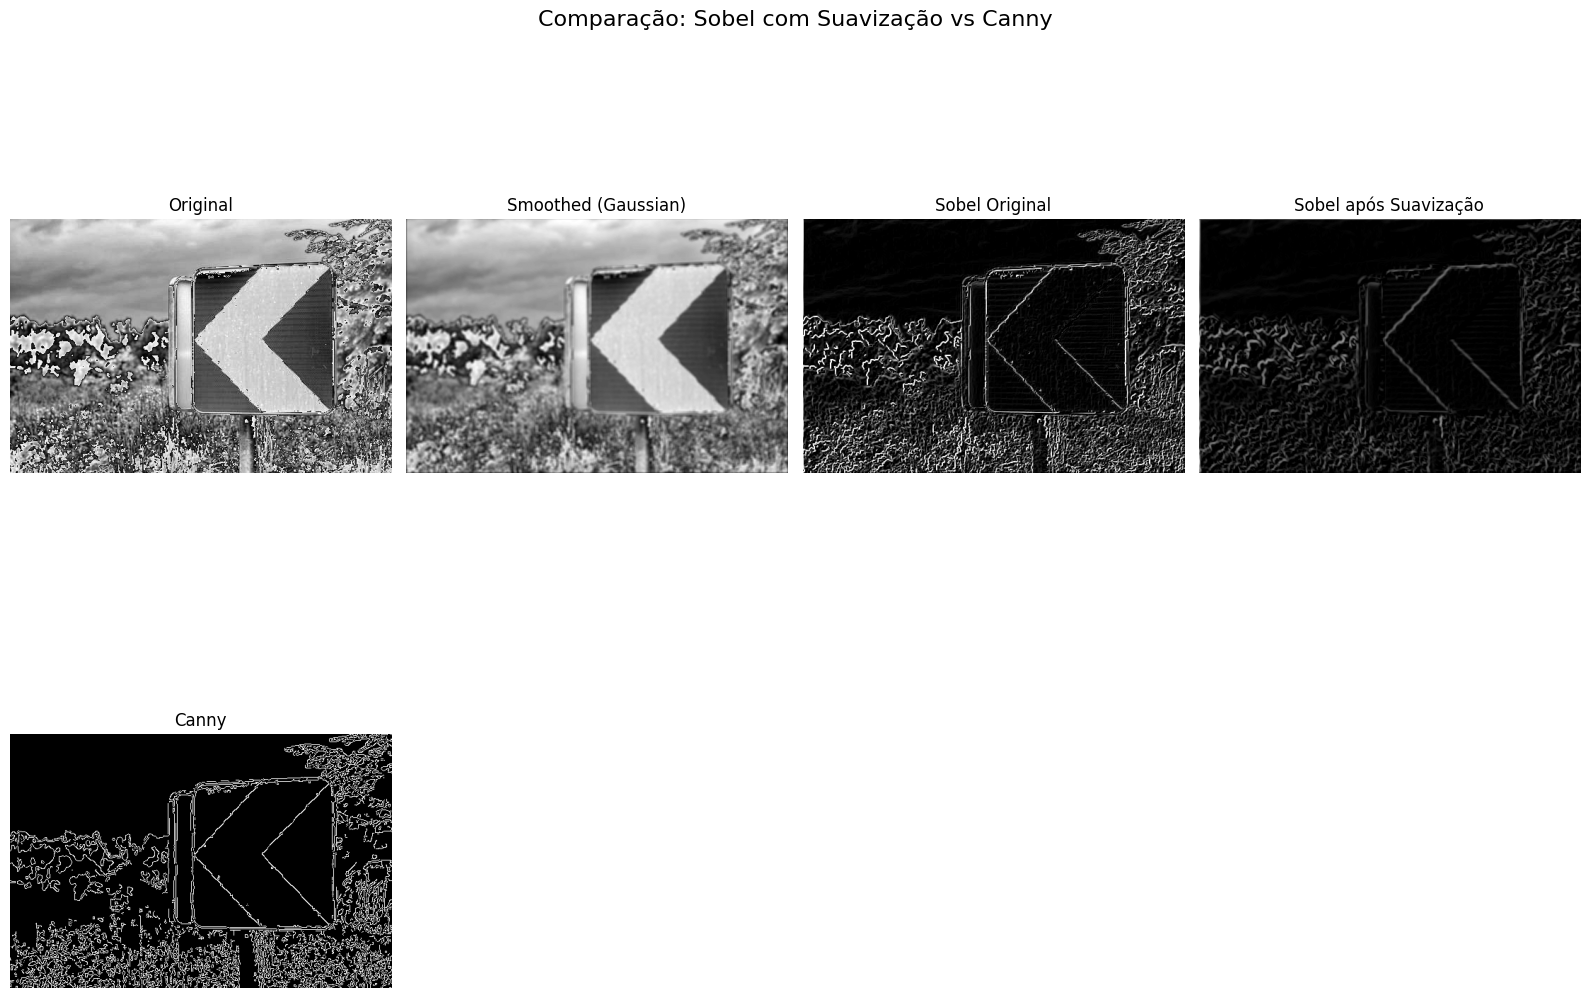

In [ ]:
# Aplicar filtro de suavização seguido de Sobel
gaussian_kernel = gaussian_filter(5, sigma=1.0)
smoothed_img = conv2d(img_gray, gaussian_kernel)
sobel_after_smooth = sobel_edge(smoothed_img)

# Comparação
comparison_results = {
    "Original": img_gray,
    "Smoothed (Gaussian)": smoothed_img,
    "Sobel Original": sobel_edge(img_gray),
    "Sobel após Suavização": sobel_after_smooth,
    "Canny": cv2.Canny(img_gray, 100, 200)
}

plot_results(comparison_results, "Comparação: Sobel com Suavização vs Canny")

#Observações
Os filtros de suavização têm como principal objetivo reduzir ruídos presentes na imagem, mas cada técnica apresenta características específicas quanto ao borramento e preservação de detalhes.

O filtro de média é simples e eficaz na redução de ruído, porém provoca borramento uniforme. Como todos os pixels recebem o mesmo peso, as bordas acabam ficando esmaecidas e menos nítidas. O efeito depende do tamanho do kernel: com dimensões pequenas (3×3 ou 5×5) o borramento é leve, enquanto kernels maiores (7×7 ou mais) causam forte suavização, apagando detalhes finos.

O filtro gaussiano, por sua vez, suaviza de maneira mais equilibrada. Como os pesos seguem a distribuição gaussiana, bordas relevantes são preservadas melhor do que no filtro de média, e o efeito de esmaecimento é mais suave e natural. Por isso, é amplamente utilizado como etapa de pré-processamento antes da detecção de bordas, como nos operadores Sobel e Canny.

Já o filtro de mediana se destaca na remoção de ruídos impulsivos, como o salt-and-pepper, sem comprometer tanto as bordas. Diferente da média e do gaussiano, ele preserva melhor linhas finas e contornos, resultando em uma imagem mais limpa, com bom contraste visual.

Os filtros de sharpening têm o objetivo oposto: realçar detalhes e aumentar a nitidez. O Laplaciano realça bordas em todas as direções, mas tende a amplificar ruídos, deixando regiões homogêneas com aparência áspera. O sharpen básico utiliza kernels simples para intensificar contornos de forma equilibrada, mantendo a nitidez sem exagero. A unsharp mask proporciona resultados mais naturais, destacando bordas de forma controlada e agradável, sem saturar a imagem. Já o highboost aplica um realce mais agressivo, com bordas muito marcadas e contraste elevado; no entanto, se o fator de amplificação for alto, o ruído também se torna bastante visível.

Entre os detectores de borda, o operador Roberts gera bordas nítidas em regiões bem definidas, mas é bastante sensível a ruídos, o que causa fragmentação. O Sobel oferece bordas mais contínuas e suaves, e seu desempenho melhora consideravelmente quando aplicado após uma suavização gaussiana. O Laplaciano detecta bordas finas em todas as direções, porém o ruído também é interpretado como falsas bordas, deixando a imagem granulada se não houver pré-processamento. Já o Canny é considerado o mais robusto: produz bordas bem definidas, contínuas e finas, com pouca interferência de ruído. Isso se deve à combinação de suavização inicial, cálculo de gradiente e supressão de bordas falsas, tornando-o o método mais preciso e limpo entre os principais detectores.